# MobileNet — Etapa 3: Avaliação do Modelo

Este notebook avalia o desempenho do MLP treinado na Etapa 2, utilizando métricas de classificação multiclasse e visualizações que permitem identificar onde o modelo acerta e onde erra.

---

## 1. Importações e Preparação dos Dados

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Define o tema visual dos gráficos
sns.set_theme(style='whitegrid')

# Diretório de saída para as imagens geradas nesta etapa
IMAGES_DIR = '../images/evaluation'
os.makedirs(IMAGES_DIR, exist_ok=True)

# Nomes descritivos das classes para uso nos gráficos
NOMES_CLASSES = ['Baixo custo', 'Custo médio', 'Alto custo', 'Custo muito alto']

In [2]:
# Leitura e preparação dos dados (mesma configuração das etapas anteriores)
train = pd.read_csv('../data/train.csv')

X = train.drop(columns='faixa_preco')
y = train['faixa_preco']

# Divisão treino/validação com estratificação
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalização — fit apenas no treino
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)

# Retrainamento do modelo com a mesma arquitetura da Etapa 2
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)
mlp.fit(X_train, y_train)

# Predições nos conjuntos de treino e validação
y_pred_treino = mlp.predict(X_train)
y_pred_val    = mlp.predict(X_val)

print('Modelo treinado e predições geradas.')

Modelo treinado e predições geradas.


---
## 2. Acurácia

A **acurácia** é a fração de amostras classificadas corretamente sobre o total:

$$\text{Acurácia} = \frac{\text{Predições corretas}}{\text{Total de amostras}} = \frac{TP + TN}{TP + TN + FP + FN}$$

Apesar de ser uma métrica intuitiva, ela pode ser enganosa em datasets desbalanceados. Como as classes estão balanceadas neste dataset, a acurácia é uma métrica confiável aqui.

In [3]:
# Cálculo da acurácia nos dois conjuntos
acc_treino = accuracy_score(y_train, y_pred_treino)
acc_val    = accuracy_score(y_val, y_pred_val)

print(f'Acurácia no treino:    {acc_treino:.4f} ({acc_treino*100:.2f}%)')
print(f'Acurácia na validação: {acc_val:.4f} ({acc_val*100:.2f}%)')

# Gap entre treino e validação — indica nível de overfitting
print(f'\nGap (treino - validação): {(acc_treino - acc_val)*100:.2f} p.p.')

Acurácia no treino:    0.9875 (98.75%)
Acurácia na validação: 0.9200 (92.00%)

Gap (treino - validação): 6.75 p.p.


---
## 3. Matriz de Confusão

A **matriz de confusão** exibe, para cada classe real (linhas), quantas amostras foram classificadas em cada classe predita (colunas). A diagonal principal representa as predições corretas.

$$C_{ij} = \text{número de amostras da classe } i \text{ preditas como classe } j$$

- **Diagonal principal** ($C_{ii}$): acertos — quanto maior, melhor
- **Fora da diagonal** ($C_{ij},\ i \neq j$): erros — confusões entre classes

A versão normalizada divide cada linha pelo total de amostras da classe real, transformando as contagens em **taxas de acerto por classe**.

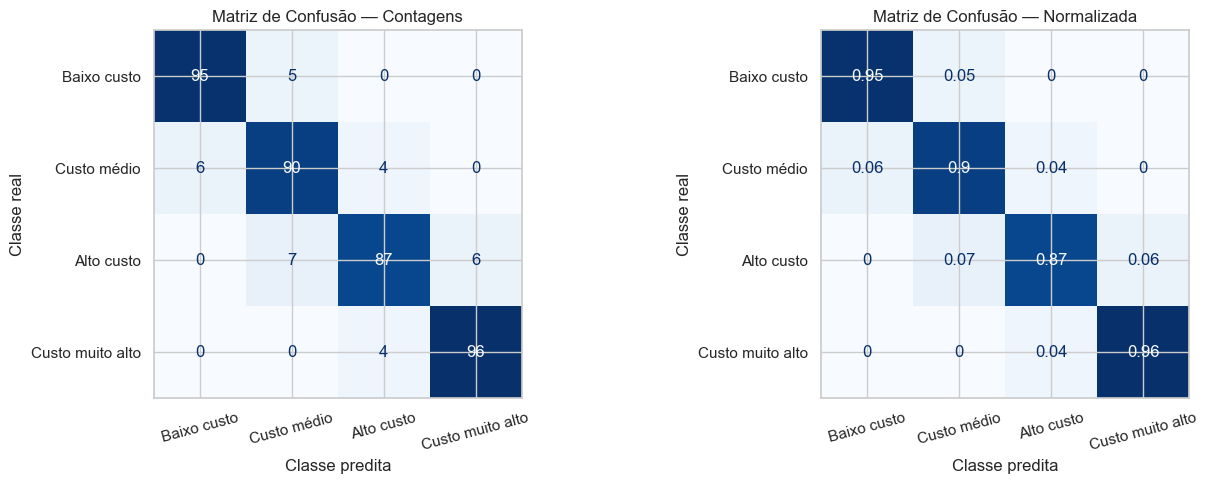

In [4]:
# Matriz de confusão absoluta (contagens)
cm = confusion_matrix(y_val, y_pred_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz com contagens absolutas
disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=NOMES_CLASSES)
disp_abs.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — Contagens', fontsize=12)
axes[0].set_xlabel('Classe predita')
axes[0].set_ylabel('Classe real')
axes[0].tick_params(axis='x', rotation=15)

# Matriz normalizada por linha (taxa de acerto por classe real)
cm_norm = confusion_matrix(y_val, y_pred_val, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=NOMES_CLASSES)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão — Normalizada', fontsize=12)
axes[1].set_xlabel('Classe predita')
axes[1].set_ylabel('Classe real')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/01_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Relatório de Classificação

O relatório de classificação detalha três métricas por classe:

**Precisão (*Precision*):** dos exemplos preditos como classe $c$, qual fração realmente pertence a ela?

$$\text{Precisão}_c = \frac{TP_c}{TP_c + FP_c}$$

**Revocação (*Recall*):** dos exemplos que realmente pertencem à classe $c$, qual fração foi corretamente identificada?

$$\text{Revocação}_c = \frac{TP_c}{TP_c + FN_c}$$

**F1-Score:** média harmônica entre precisão e revocação — penaliza modelos que sacrificam uma métrica pela outra:

$$\text{F1}_c = 2 \cdot \frac{\text{Precisão}_c \times \text{Revocação}_c}{\text{Precisão}_c + \text{Revocação}_c}$$

Onde:
- $TP_c$ — verdadeiros positivos da classe $c$
- $FP_c$ — falsos positivos (outras classes preditas como $c$)
- $FN_c$ — falsos negativos (instâncias de $c$ preditas como outra classe)

In [5]:
# Relatório textual com precisão, revocação e F1-score por classe
print('Relatório de Classificação — Validação\n')
print(classification_report(y_val, y_pred_val, target_names=NOMES_CLASSES))

Relatório de Classificação — Validação

                  precision    recall  f1-score   support

     Baixo custo       0.94      0.95      0.95       100
     Custo médio       0.88      0.90      0.89       100
      Alto custo       0.92      0.87      0.89       100
Custo muito alto       0.94      0.96      0.95       100

        accuracy                           0.92       400
       macro avg       0.92      0.92      0.92       400
    weighted avg       0.92      0.92      0.92       400



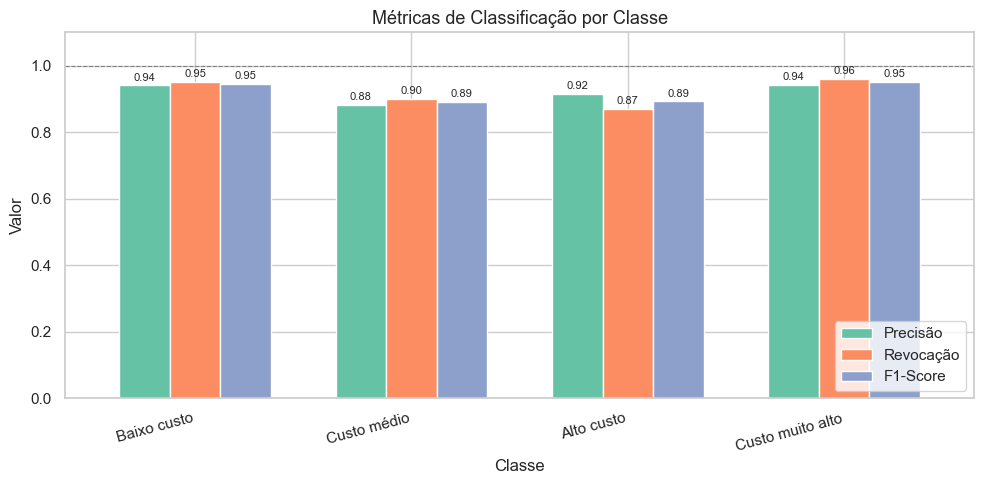

In [6]:
# Visualização das métricas por classe em gráfico de barras agrupadas
relatorio = classification_report(
    y_val, y_pred_val,
    target_names=NOMES_CLASSES,
    output_dict=True  # retorna dicionário para facilitar a plotagem
)

# Extrai apenas as métricas por classe (exclui médias globais)
metricas_df = pd.DataFrame(relatorio).T.loc[NOMES_CLASSES, ['precision', 'recall', 'f1-score']]
metricas_df.columns = ['Precisão', 'Revocação', 'F1-Score']

fig, ax = plt.subplots(figsize=(10, 5))
metricas_df.plot(kind='bar', ax=ax, width=0.7,
                 color=sns.color_palette('Set2', 3))

ax.set_title('Métricas de Classificação por Classe', fontsize=13)
ax.set_xlabel('Classe')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.1)
ax.set_xticklabels(NOMES_CLASSES, rotation=15, ha='right')
ax.legend(loc='lower right')
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)

# Rótulos de valor no topo de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/02_metrics_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Análise de Erros

Identificar sistematicamente quais amostras foram classificadas incorretamente ajuda a entender as limitações do modelo e orientar o ajuste de hiperparâmetros na próxima etapa.

In [7]:
# Cria DataFrame com os resultados da validação
resultados = X_val_raw.copy()
resultados['classe_real']   = y_val.values
resultados['classe_predita'] = y_pred_val
resultados['correto']       = (resultados['classe_real'] == resultados['classe_predita'])

# Amostras classificadas incorretamente
erros = resultados[~resultados['correto']]

print(f'Total de erros: {len(erros)} de {len(resultados)} amostras ({len(erros)/len(resultados)*100:.1f}%)')
print('\nErros por classe real:')
print(erros['classe_real'].value_counts().sort_index().to_string())

Total de erros: 32 de 400 amostras (8.0%)

Erros por classe real:
classe_real
0     5
1    10
2    13
3     4


In [8]:
# Distribuição dos erros: classe real vs. classe predita
tabela_erros = erros.groupby(['classe_real', 'classe_predita']).size().reset_index(name='contagem')
tabela_erros['classe_real']    = tabela_erros['classe_real'].map(dict(enumerate(NOMES_CLASSES)))
tabela_erros['classe_predita'] = tabela_erros['classe_predita'].map(dict(enumerate(NOMES_CLASSES)))

print('Confusões mais frequentes:')
print(tabela_erros.sort_values('contagem', ascending=False).to_string(index=False))

Confusões mais frequentes:
     classe_real   classe_predita  contagem
      Alto custo      Custo médio         7
     Custo médio      Baixo custo         6
      Alto custo Custo muito alto         6
     Baixo custo      Custo médio         5
     Custo médio       Alto custo         4
Custo muito alto       Alto custo         4


---
## 6. Resumo da Avaliação

| Métrica                  | Treino   | Validação |
|--------------------------|----------|-----------|
| Acurácia                 | —        | —         |
| F1-Score médio (macro)   | —        | —         |

> Os valores serão preenchidos após a execução das células acima.

Com base nas métricas obtidas, a **Etapa 4** focará no ajuste de hiperparâmetros para maximizar o F1-Score na validação.